In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [2]:
scores = np.load("/content/feature_importances.npy")
idx = np.load("/content/feature_ranking_idx.npy")

In [ ]:
vertic = np.array([]*35)
for i in range(len(vertic)):
  vertic[i] = 368*(i+1)

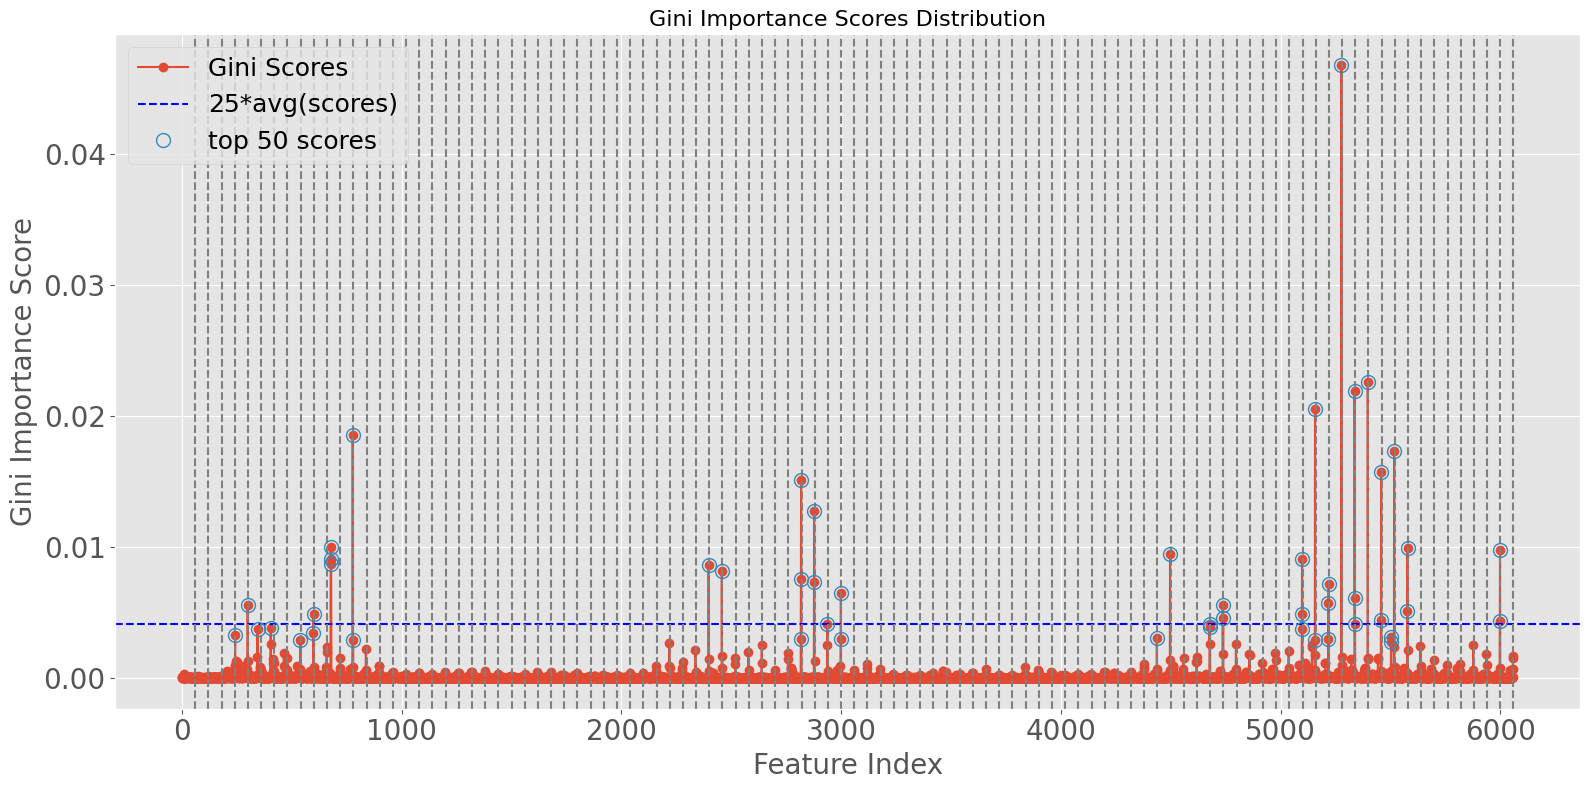

In [4]:
plt.figure(figsize=(16,8))
plt.plot(scores, "-o", label="Gini Scores")
plt.axhline(25*np.mean(scores), color="blue", linestyle='--', label="25*avg(scores)")
for i in range(101):
  plt.axvline(60*(i+1), color="gray", linestyle='--')
plt.plot(
    idx[:50],
    np.sort(scores)[::-1][:50],
    'o',
    markersize=10,
    markeredgewidth=1,
    markerfacecolor='none',
    label="top 50 scores"
)
plt.title("Gini Importance Scores Distribution", fontsize=16)
plt.xlabel("Feature Index", fontsize=20)
plt.ylabel("Gini Importance Score", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

In [5]:
# all_indices = []
all_scores = []
for i in range(101):
  # indices = idx[(i)*60:(i+1)*60]
  score = scores[(i)*60:(i+1)*60]
  # print(indices)
  # all_indices.append(indices)
  all_scores.append(score)
# all_indices = np.array(all_indices)
all_scores = np.array(all_scores)

In [6]:
len(np.sum(all_scores, axis=0))

60

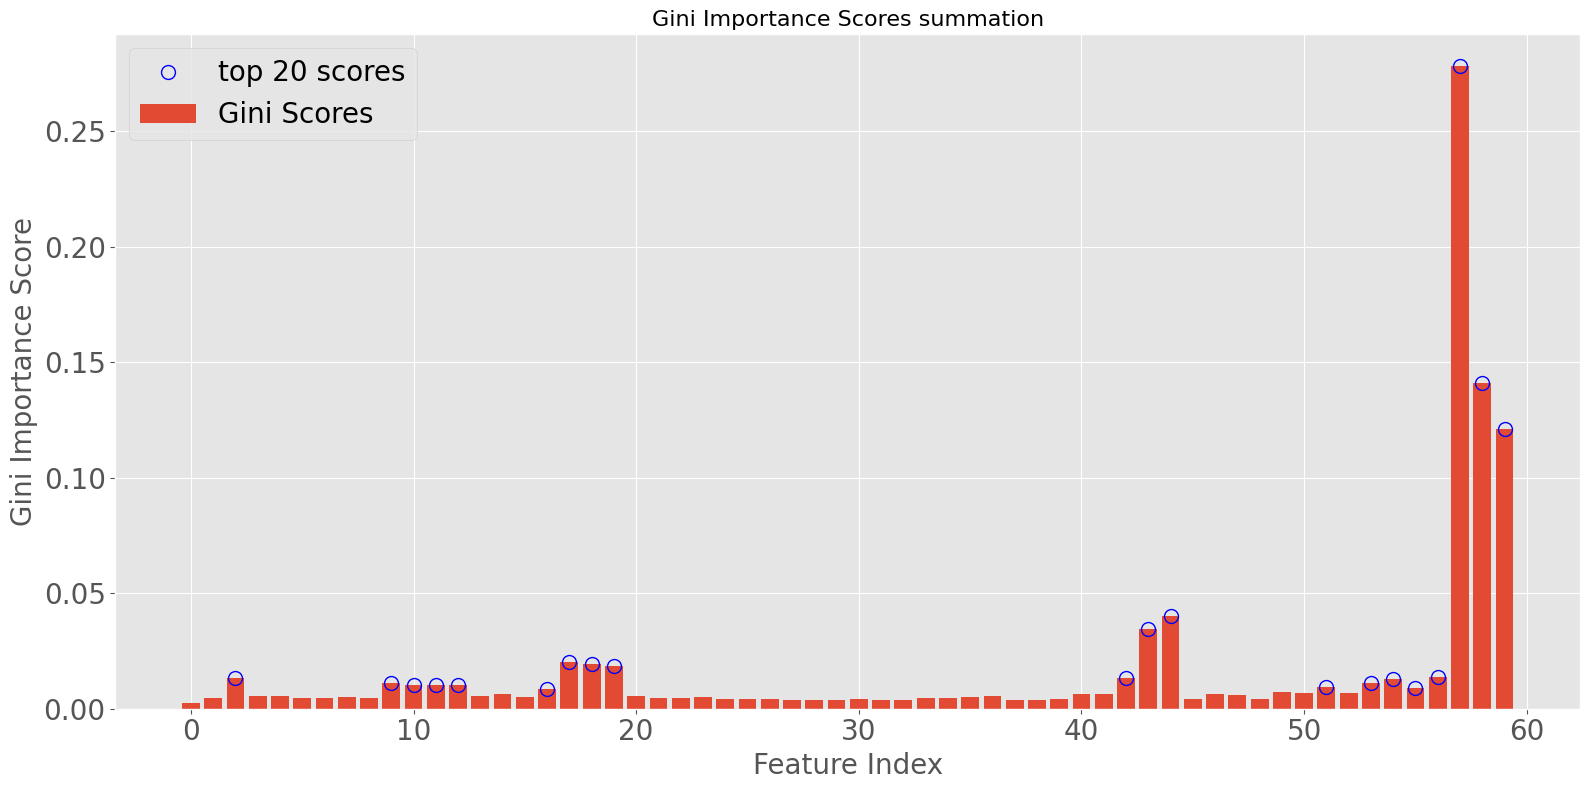

In [11]:
plt.figure(figsize=(16,8))

plt.bar(np.arange(60), np.sum(all_scores, axis=0), label="Gini Scores")

plt.plot(
    np.argsort(np.sum(all_scores, axis=0))[::-1][:20],
    np.sort(np.sum(all_scores, axis=0))[::-1][:20],
    'o',
    markersize=10,
    markeredgewidth=1,
    markerfacecolor='none',
    label="top 20 scores",
    color='blue'
)
plt.title("Gini Importance Scores summation", fontsize=16)
plt.xlabel("Feature Index", fontsize=20)
plt.ylabel("Gini Importance Score", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()

per sensor scores

In [12]:
import pandas as pd

f_values= np.linspace(1000, 50000, 101)
df = pd.DataFrame()
df["indices"] = np.arange(60)
for i, f in enumerate(f_values):
  df[f"scores_{int(f)}"] = scores[(i)*60:(i+1)*60]

/tmp/ipython-input-1943000469.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"scores_{int(f)}"] = scores[(i)*60:(i+1)*60]
/tmp/ipython-input-1943000469.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"scores_{int(f)}"] = scores[(i)*60:(i+1)*60]


In [13]:
df.describe()

,indices,scores_1000,scores_1490,scores_1980,scores_2470,scores_2960,scores_3450,scores_3940,scores_4430,scores_4920,...,scores_45590,scores_46080,scores_46570,scores_47060,scores_47550,scores_48040,scores_48530,scores_49020,scores_49510,scores_50000
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,...,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,29.500000,0.000063,0.000051,0.000067,0.000114,0.000410,0.000246,0.000261,0.000175,0.000167,...,0.000585,0.000406,0.000140,0.000148,0.000101,0.000126,0.000123,0.000117,0.000310,0.000134
std,17.464249,0.000040,0.000030,0.000035,0.000121,0.000837,0.000551,0.000628,0.000340,0.000398,...,0.002274,0.001436,0.000340,0.000214,0.000149,0.000197,0.000330,0.000263,0.001366,0.000309
min,0.000000,0.000031,0.000024,0.000033,0.000035,0.000048,0.000031,0.000029,0.000026,0.000030,...,0.000020,0.000019,0.000018,0.000019,0.000021,0.000019,0.000018,0.000017,0.000018,0.000018
25%,14.750000,0.000037,0.000030,0.000040,0.000056,0.000076,0.000050,0.000043,0.000043,0.000049,...,0.000057,0.000051,0.000042,0.000040,0.000038,0.000036,0.000036,0.000035,0.000037,0.000032
50%,29.500000,0.000055,0.000038,0.000054,0.000076,0.000129,0.000082,0.000059,0.000062,0.000069,...,0.000096,0.000086,0.000067,0.000082,0.000051,0.000052,0.000054,0.000051,0.000053,0.000045
75%,44.250000,0.000067,0.000056,0.000087,0.000105,0.000370,0.000138,0.000117,0.000103,0.000104,...,0.000327,0.000166,0.000093,0.000181,0.000091,0.000125,0.000072,0.000083,0.000083,0.000066
max,59.000000,0.000289,0.000171,0.000192,0.000736,0.005563,0.003750,0.003810,0.001934,0.002949,...,0.017300,0.009909,0.002494,0.001417,0.001040,0.001083,0.002519,0.001833,0.009789,0.001710


In [14]:
# select score columns
score_cols = [c for c in df.columns if c.startswith("scores_")]

# mean score per frequency (column-wise)
mean_scores = df[score_cols].mean(axis=0)

# sort from high to low
mean_scores_sorted = mean_scores.sort_values(ascending=False)

# mean_scores_sorted

In [15]:
best_frequencies = mean_scores_sorted.index.str.replace("scores_", "").astype(int)
# best_frequencies

In [16]:
# plt.plot(np.sort(best_frequencies), mean_scores_sorted, "o-")
test_df = pd.DataFrame()
test_df['freq'] = best_frequencies
test_df["mean"] = mean_scores_sorted.values
test_df = test_df.sort_values(by="freq")

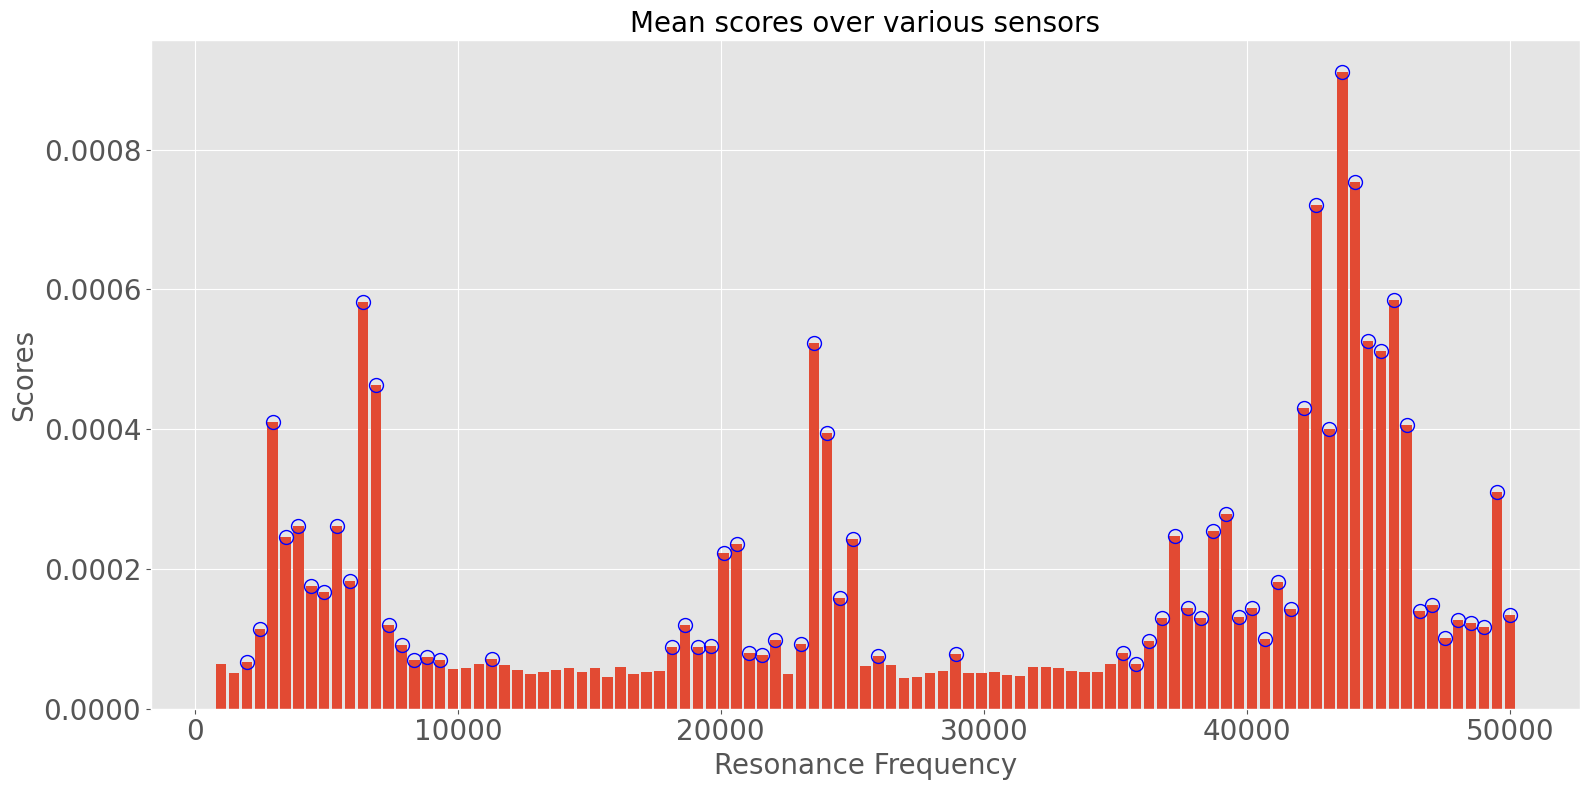

In [28]:
plt.figure(figsize=(16,8))
plt.bar(x=test_df['freq'], height=test_df['mean'], width=400)
plt.plot(
    test_df.sort_values(by="mean", ascending=False)["freq"][:64],
    test_df.sort_values(by="mean", ascending=False)["mean"][:64],
    'o',
    markersize=10,
    markeredgewidth=1,
    markerfacecolor='none',
    label="top 64 sensors",
    color='blue'
)
plt.xlabel("Resonance Frequency", fontsize=20)
plt.ylabel("Scores", fontsize=20)
plt.title("Mean scores over various sensors", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.show()

In [30]:
np.array(test_df.sort_values(by="mean", ascending=False)["freq"][:64])

array([43630, 44120, 42650, 45590,  6390, 44610, 23540, 45100,  6880,
       42160,  2960, 46080, 43140, 24030, 49510, 39220,  3940,  5410,
       38730, 37260,  3450, 25010, 20600, 20110,  5900, 41180,  4430,
        4920, 24520, 47060, 40200, 37750, 41670, 46570, 50000, 39710,
       38240, 36770, 48040, 48530,  7370, 18640, 49020,  2470, 47550,
       40690, 22070, 36280, 23050,  7860, 19620, 18150, 19130, 35300,
       21090, 28930, 21580, 25990,  8840, 11290,  8350,  9330,  1980,
       35790])

In [ ]:
test_df.sort_values(by="mean", ascending=False)["freq"].to_numpy(dtype=int)

np.save("top-sens.npy",test_df.sort_values(by="mean", ascending=False)["freq"].to_numpy(dtype=int))